# Feature Engineering & Feature Selection

**Instructor:** Adil Rasheed, Department of Engineering Cybernetics

---

### What you already know
- Least Squares & Multiple Linear Regression (MLR)
- Principal Component Analysis (PCA) & PCR
- Partial Least Squares Regression (PLSR)
- Independent Component Analysis (ICA)
- t-SNE for visualisation
- Regularisation: Ridge ($L_2$) and Lasso ($L_1$)

### What this notebook adds
1. **Feature Engineering** — using domain knowledge to create better representations
2. **Feature Selection** — choosing the right subset to avoid overfitting and improve predictions
3. **The critical role of pipelines** — preventing data leakage

### Scenario: Maritime Engine Health Monitoring

We will work with a **synthetic but realistic** dataset simulating sensor readings from ship engines. The goal is to **predict fuel efficiency** (kg fuel per nautical mile) from sensor data, operational parameters, and maintenance records.

> **Key rule to memorise:** *Anything that learns from data must be fit on training folds only.*


---
## Part 1: Data Generation & Exploration

We generate a synthetic maritime dataset where we *know the ground truth* — this is pedagogically powerful because we can verify whether our methods recover the true signal.

**True data-generating process:**
$$\text{fuel\_efficiency} = \beta_0 + \beta_1 \cdot \text{RPM} + \beta_2 \cdot \text{draft} + \beta_3 \cdot \text{wave\_height}^2 + \beta_4 \cdot \frac{\text{power}}{\text{speed}} + \beta_5 \cdot \text{engine\_age} + \varepsilon$$

Notice:
- There is a **non-linear** term ($\text{wave\_height}^2$)
- There is a **ratio** feature ($\text{power}/\text{speed}$) — this is domain knowledge!
- `engine_age` has a real but small effect
- We will also include **noise features** that have no true relationship


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

# -------------------------------------------------------------------
# Generate synthetic maritime engine dataset
# -------------------------------------------------------------------
n_samples = 600
n_vessels = 12

# Vessel metadata
vessel_ids = np.random.choice(range(n_vessels), size=n_samples)
engine_ages = np.array([np.random.uniform(1, 25) for _ in range(n_vessels)])
vessel_engine_age = engine_ages[vessel_ids]
vessel_classes = np.array(['Tanker', 'Bulk', 'Container', 'RoRo'])[vessel_ids % 4]

# Operational parameters (these are the meaningful signals)
rpm = np.random.uniform(60, 120, n_samples)                    # engine RPM
speed_knots = np.random.uniform(8, 22, n_samples)              # vessel speed
draft_m = np.random.uniform(6, 16, n_samples)                  # draft in metres
wave_height = np.random.exponential(1.5, n_samples)             # significant wave height
wave_height = np.clip(wave_height, 0.2, 8)
power_kw = 0.5 * rpm * speed_knots + np.random.normal(0, 50, n_samples)  # correlated with rpm & speed
oil_temp = 70 + 0.3 * rpm + np.random.normal(0, 5, n_samples)  # correlated with RPM
coolant_temp = 60 + 0.2 * rpm + np.random.normal(0, 4, n_samples)

# Time features
hour_of_day = np.random.randint(0, 24, n_samples)
month = np.random.choice(range(1, 13), n_samples)

# Vibration (spectral) — higher for older engines and high RPM
vibration_rms = 0.01 * rpm + 0.05 * vessel_engine_age + np.random.normal(0, 0.3, n_samples)

# NOISE features (no true relationship to target)
noise_sensor_1 = np.random.normal(0, 1, n_samples)
noise_sensor_2 = np.random.uniform(-5, 5, n_samples)
noise_sensor_3 = np.random.normal(100, 15, n_samples)
noise_categorical = np.random.choice(['A', 'B', 'C', 'D'], n_samples)

# -------------------------------------------------------------------
# TRUE DATA-GENERATING PROCESS for fuel efficiency
# -------------------------------------------------------------------
power_speed_ratio = power_kw / (speed_knots + 0.1)  # domain feature

fuel_efficiency = (
    2.0                              # intercept
    + 0.03 * rpm                     # RPM effect
    + 0.15 * draft_m                 # draft effect
    + 0.08 * wave_height**2          # NON-LINEAR wave effect
    + 0.005 * power_speed_ratio      # domain ratio feature
    + 0.02 * vessel_engine_age       # aging effect
    + np.random.normal(0, 0.4, n_samples)  # irreducible noise
)

# Introduce ~5% missing values in some columns (realistic)
oil_temp_with_missing = oil_temp.copy()
coolant_temp_with_missing = coolant_temp.copy()
missing_idx_oil = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
missing_idx_cool = np.random.choice(n_samples, size=int(0.03 * n_samples), replace=False)
oil_temp_with_missing[missing_idx_oil] = np.nan
coolant_temp_with_missing[missing_idx_cool] = np.nan

# Introduce a few outliers in vibration
outlier_idx = np.random.choice(n_samples, size=8, replace=False)
vibration_rms_with_outliers = vibration_rms.copy()
vibration_rms_with_outliers[outlier_idx] = vibration_rms[outlier_idx] + np.random.uniform(5, 10, 8)

# -------------------------------------------------------------------
# Assemble DataFrame
# -------------------------------------------------------------------
df = pd.DataFrame({
    'vessel_id': vessel_ids,
    'vessel_class': vessel_classes,
    'engine_age_years': vessel_engine_age,
    'rpm': rpm,
    'speed_knots': speed_knots,
    'draft_m': draft_m,
    'power_kw': power_kw,
    'wave_height_m': wave_height,
    'oil_temp_C': oil_temp_with_missing,
    'coolant_temp_C': coolant_temp_with_missing,
    'vibration_rms': vibration_rms_with_outliers,
    'hour_of_day': hour_of_day,
    'month': month,
    'noise_sensor_1': noise_sensor_1,
    'noise_sensor_2': noise_sensor_2,
    'noise_sensor_3': noise_sensor_3,
    'noise_category': noise_categorical,
    'fuel_efficiency': fuel_efficiency,
})

print(f"Dataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTarget statistics:\n{df['fuel_efficiency'].describe()}")
df.head(10)


Dataset shape: (600, 18)

Missing values:
oil_temp_C        30
coolant_temp_C    18
dtype: int64

Target statistics:
count    600.000000
mean       7.211868
std        1.091604
min        4.044926
25%        6.498485
50%        7.116466
75%        7.767683
max       12.453229
Name: fuel_efficiency, dtype: float64


,vessel_id,vessel_class,engine_age_years,rpm,speed_knots,draft_m,power_kw,wave_height_m,oil_temp_C,coolant_temp_C,vibration_rms,hour_of_day,month,noise_sensor_1,noise_sensor_2,noise_sensor_3,noise_category,fuel_efficiency
0,6,Container,24.004996,89.581539,8.618316,10.568586,401.321733,1.456693,106.087719,84.389833,10.132391,23,4,-0.844328,-4.213023,112.158669,A,6.649543
1,3,RoRo,8.143244,64.997065,16.235693,7.903249,580.369496,1.228694,92.433881,71.955228,1.181511,7,8,0.642373,0.273109,113.510616,C,5.948333
2,10,Container,17.242478,65.502249,21.990949,6.523389,743.400460,1.484253,NaN,72.041879,1.709117,20,1,0.030748,-0.972145,86.226949,B,5.615355
3,7,RoRo,21.331435,96.146456,15.781292,9.784764,785.983783,1.141098,100.497991,73.776978,1.633271,23,3,-2.329442,0.888103,109.614412,C,7.565343
4,4,Tanker,3.399637,93.222183,14.624942,9.629443,726.413379,1.512153,NaN,76.082846,1.010086,5,1,-0.574382,-4.107778,109.979073,D,6.808762
5,6,Container,24.004996,72.763674,12.379968,15.954805,344.572788,0.896325,93.039890,71.283553,2.288114,20,9,0.334838,-0.690169,84.684055,C,6.485904
6,9,Bulk,23.963221,116.771673,9.687316,10.463524,541.104544,0.369701,101.462047,80.293445,2.545913,6,2,-0.406001,-3.252133,95.220756,A,8.277926
7,2,Container,10.350834,106.877763,18.234331,9.335695,997.852565,0.200000,110.514217,81.400691,1.467755,23,9,-2.546732,4.871001,78.158319,D,6.283830
8,6,Container,24.004996,66.807876,10.696386,11.804750,426.683644,0.200000,94.669353,63.624870,1.689071,0,4,1.320750,0.611502,110.044339,A,5.707892
9,10,Container,17.242478,115.855746,9.613948,6.887674,560.220356,0.458394,104.915632,77.130228,2.605155,17,2,0.169375,1.874369,109.975337,D,6.791961


### Exercise for students
> Before we begin engineering features, **look at the raw data**. Which features do you *expect* to matter for fuel efficiency based on your physical intuition? Write down your top 5 predictions.

---
### 1.1 Exploratory Data Analysis


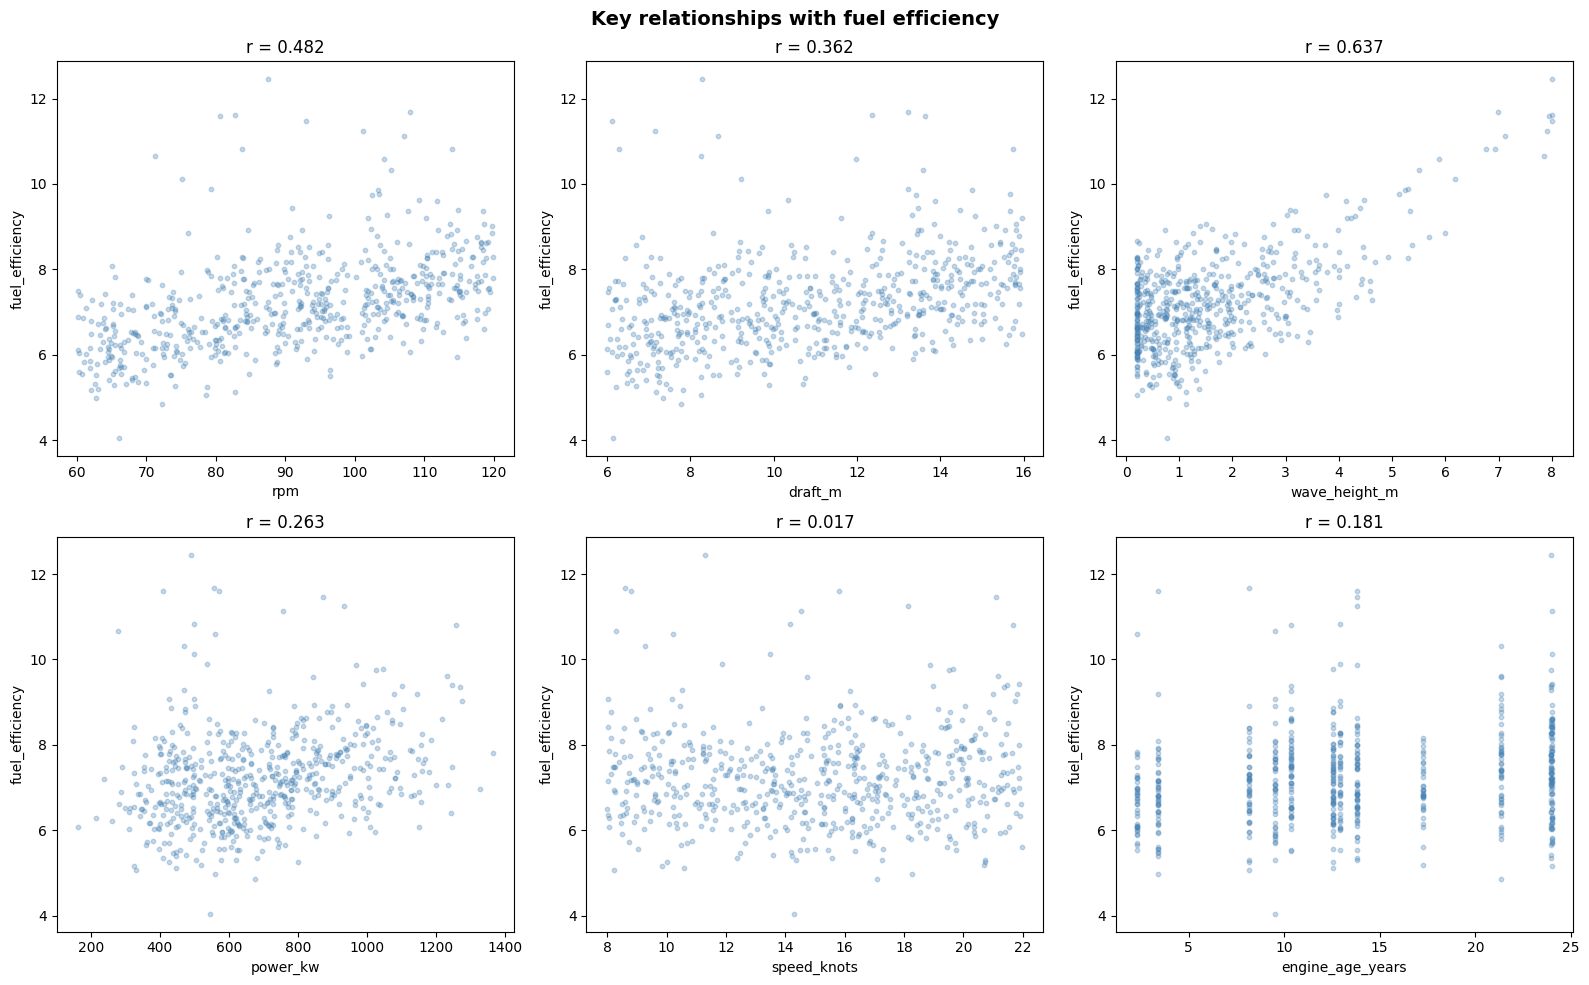

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key relationships with fuel efficiency', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, ['rpm', 'draft_m', 'wave_height_m', 'power_kw', 'speed_knots', 'engine_age_years']):
    ax.scatter(df[col], df['fuel_efficiency'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('fuel_efficiency')
    # Add correlation coefficient
    r = df[[col, 'fuel_efficiency']].dropna().corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}')

plt.tight_layout()
plt.show()


**Observations:**
- `rpm` and `draft_m` show clear linear trends — these are true signal features.
- `wave_height_m` has a relationship, but it's **not linear** — this is the $\text{wave}^2$ term. A linear correlation underestimates its importance!
- `power_kw` is correlated but is also correlated with `rpm` (multicollinearity).
- `speed_knots` alone shows weak correlation because its true role is in the *ratio* $\text{power}/\text{speed}$.

> **Lesson:** Pairwise scatter plots and correlations can miss non-linear effects and interaction terms. Domain knowledge fills this gap.


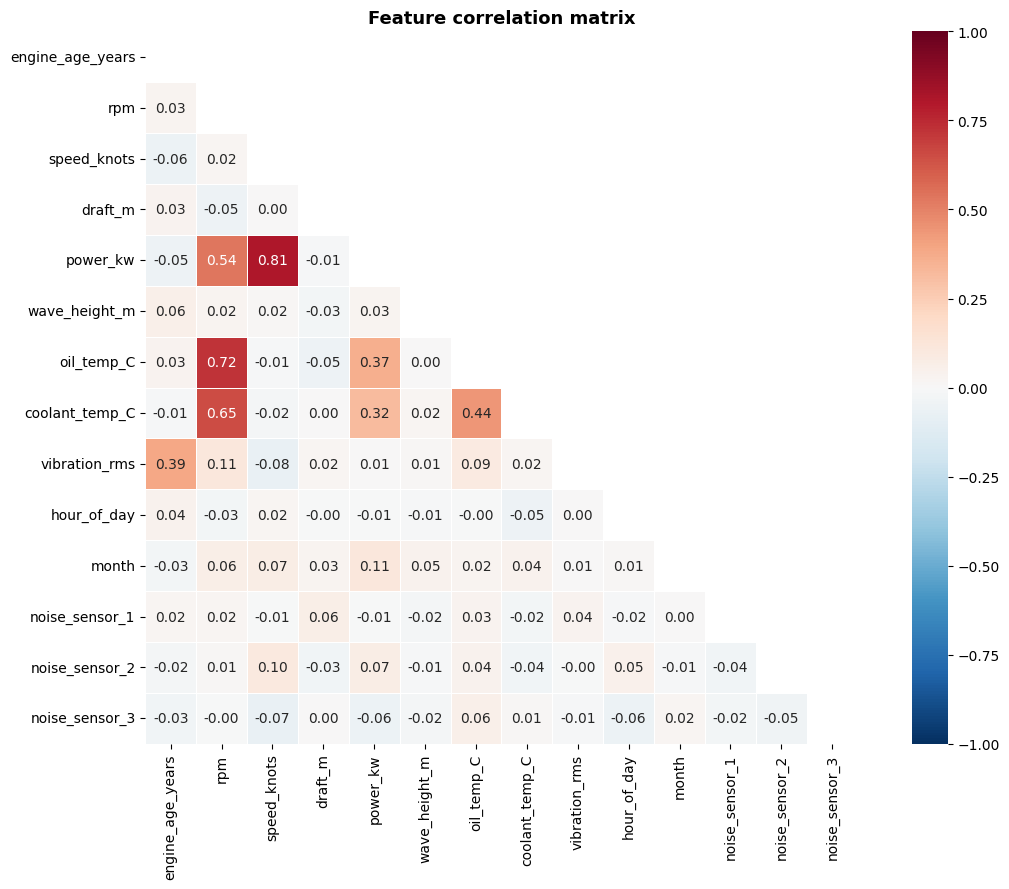

In [3]:
# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['vessel_id', 'fuel_efficiency'])
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Key observations from the correlation matrix:**
- `oil_temp_C` and `rpm` are highly correlated ($r \approx 0.95$) — **redundancy**
- `coolant_temp_C` and `rpm` are also correlated — another redundant sensor
- `power_kw` correlates with both `rpm` and `speed_knots` — by construction
- The **noise features** show near-zero correlation with everything — as expected

> **Insight:** High inter-feature correlation is a sign of **multicollinearity**, which you've seen destabilise OLS coefficients. Feature engineering and selection help address this.

---


## Part 2: Baseline — Raw Features + OLS

Before engineering any features, let's establish a **baseline** using raw numeric features and ordinary least squares. This gives us a reference point.

We use **GroupKFold** cross-validation — splitting by vessel — to prevent entity leakage.


In [4]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

# Define raw numeric features (no engineering yet)
raw_numeric = ['rpm', 'speed_knots', 'draft_m', 'power_kw', 'wave_height_m',
               'oil_temp_C', 'coolant_temp_C', 'vibration_rms',
               'engine_age_years', 'hour_of_day', 'month',
               'noise_sensor_1', 'noise_sensor_2', 'noise_sensor_3']

X_raw = df[raw_numeric].copy()
y = df['fuel_efficiency'].copy()
groups = df['vessel_id'].values

# Pipeline: impute → scale → OLS
baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# GroupKFold CV (4 folds — each fold holds out ~3 vessels)
gkf = GroupKFold(n_splits=4)
baseline_scores = cross_val_score(baseline_pipe, X_raw, y, cv=gkf,
                                   groups=groups, scoring='r2')

print("=" * 55)
print("BASELINE: Raw numeric features + OLS")
print("=" * 55)
print(f"R² per fold: {baseline_scores.round(4)}")
print(f"Mean R²:     {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")
print(f"Num features: {X_raw.shape[1]}")


BASELINE: Raw numeric features + OLS
R² per fold: [0.7779 0.7894 0.7583 0.7983]
Mean R²:     0.7810 ± 0.0149
Num features: 14


The baseline captures *some* of the variance but misses the non-linear and ratio terms that are part of the true data-generating process.

> **Question for students:** Why is the $R^2$ not higher, given that we have the true signal features in the dataset? Think about what's missing.

---


## Part 3: Feature Engineering with Domain Knowledge

This is where **physical understanding** of the problem dramatically improves our model. We'll engineer features in four categories:

### 3.1 Ratio features (physics-motivated)

In marine engineering, **specific fuel consumption** relates to the power delivered per unit speed. The ratio $\text{power}/\text{speed}$ captures the resistance the hull encounters.


In [5]:
# =======================================================
# 3.1 RATIO FEATURES — Physics-motivated
# =======================================================
df['power_per_speed'] = df['power_kw'] / (df['speed_knots'] + 0.1)  # avoid division by zero
df['fuel_per_rpm'] = df['power_kw'] / (df['rpm'] + 1)

print("Ratio features created:")
print(f"  power_per_speed: mean={df['power_per_speed'].mean():.1f}, "
      f"corr with target = {df['power_per_speed'].corr(df['fuel_efficiency']):.4f}")
print(f"  fuel_per_rpm:    mean={df['fuel_per_rpm'].mean():.1f}, "
      f"corr with target = {df['fuel_per_rpm'].corr(df['fuel_efficiency']):.4f}")


Ratio features created:
  power_per_speed: mean=45.3, corr with target = 0.4201
  fuel_per_rpm:    mean=7.5, corr with target = -0.0158


### 3.2 Non-linear transforms

From fluid dynamics, wave resistance scales roughly with $H_s^2$ (significant wave height squared). A linear model on raw `wave_height_m` misses this.


In [6]:
# =======================================================
# 3.2 NON-LINEAR TRANSFORMS
# =======================================================
df['wave_height_sq'] = df['wave_height_m'] ** 2
df['log_power'] = np.log1p(df['power_kw'])  # log transform for skewed feature
df['rpm_squared'] = df['rpm'] ** 2           # quadratic RPM effect (diminishing returns)

# Interaction term: wave × speed (rough seas at high speed = worse efficiency)
df['wave_speed_interaction'] = df['wave_height_m'] * df['speed_knots']

print("Non-linear features created:")
for feat in ['wave_height_sq', 'log_power', 'rpm_squared', 'wave_speed_interaction']:
    r = df[feat].corr(df['fuel_efficiency'])
    print(f"  {feat:30s} corr = {r:.4f}")


Non-linear features created:
  wave_height_sq                 corr = 0.6689
  log_power                      corr = 0.2430
  rpm_squared                    corr = 0.4741
  wave_speed_interaction         corr = 0.5833


### 3.3 Cyclical encoding of time features

Hour-of-day and month are **cyclical**: hour 23 is close to hour 0, but if we feed the raw integer, the model sees them as far apart.

**Solution:** encode as sine/cosine pairs:
$$h \mapsto \left(\sin\frac{2\pi h}{24},\; \cos\frac{2\pi h}{24}\right)$$


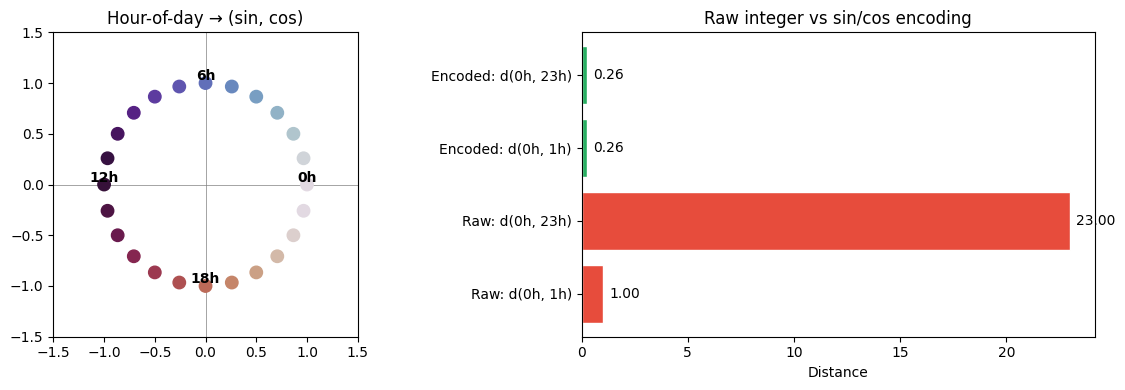


→ With cyclical encoding, hours 0 and 23 are CLOSE (distance 0.26)
  With raw integers, they appear FAR apart (distance 23)


In [7]:
# =======================================================
# 3.3 CYCLICAL ENCODING
# =======================================================
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Visualise the encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hour encoding
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)
axes[0].scatter(np.cos(theta), np.sin(theta), c=range(24), cmap='twilight', s=80, zorder=3)
for h in [0, 6, 12, 18]:
    axes[0].annotate(f'{h}h', (np.cos(2*np.pi*h/24), np.sin(2*np.pi*h/24)),
                     fontsize=10, fontweight='bold', ha='center', va='bottom')
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-1.5, 1.5)
axes[0].set_aspect('equal')
axes[0].set_title('Hour-of-day → (sin, cos)')
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)

# Raw vs encoded distance comparison
hours = np.array([0, 1, 23])
raw_dist_0_1 = abs(0 - 1)
raw_dist_0_23 = abs(0 - 23)
enc_0 = np.array([np.sin(0), np.cos(0)])
enc_1 = np.array([np.sin(2*np.pi*1/24), np.cos(2*np.pi*1/24)])
enc_23 = np.array([np.sin(2*np.pi*23/24), np.cos(2*np.pi*23/24)])
enc_dist_0_1 = np.linalg.norm(enc_0 - enc_1)
enc_dist_0_23 = np.linalg.norm(enc_0 - enc_23)

labels = ['Raw: d(0h, 1h)', 'Raw: d(0h, 23h)', 'Encoded: d(0h, 1h)', 'Encoded: d(0h, 23h)']
values = [raw_dist_0_1, raw_dist_0_23, enc_dist_0_1, enc_dist_0_23]
colors = ['#e74c3c', '#e74c3c', '#27ae60', '#27ae60']
bars = axes[1].barh(labels, values, color=colors, edgecolor='white')
axes[1].set_xlabel('Distance')
axes[1].set_title('Raw integer vs sin/cos encoding')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n→ With cyclical encoding, hours 0 and 23 are CLOSE (distance 0.26)")
print("  With raw integers, they appear FAR apart (distance 23)")


### 3.4 Missingness indicators

Missing sensor readings can be **informative** — a sensor going offline may signal hardware degradation. We create binary indicators before imputation.


In [8]:
# =======================================================
# 3.4 MISSINGNESS INDICATORS
# =======================================================
df['oil_temp_missing'] = df['oil_temp_C'].isnull().astype(int)
df['coolant_temp_missing'] = df['coolant_temp_C'].isnull().astype(int)

print(f"Oil temp missing:     {df['oil_temp_missing'].sum()} samples ({df['oil_temp_missing'].mean()*100:.1f}%)")
print(f"Coolant temp missing: {df['coolant_temp_missing'].sum()} samples ({df['coolant_temp_missing'].mean()*100:.1f}%)")


Oil temp missing:     30 samples (5.0%)
Coolant temp missing: 18 samples (3.0%)


### 3.5 Handling outliers

We saw that `vibration_rms` contains outliers (simulating faulty sensor readings). **Winsorisation** clips extreme values to a percentile boundary.


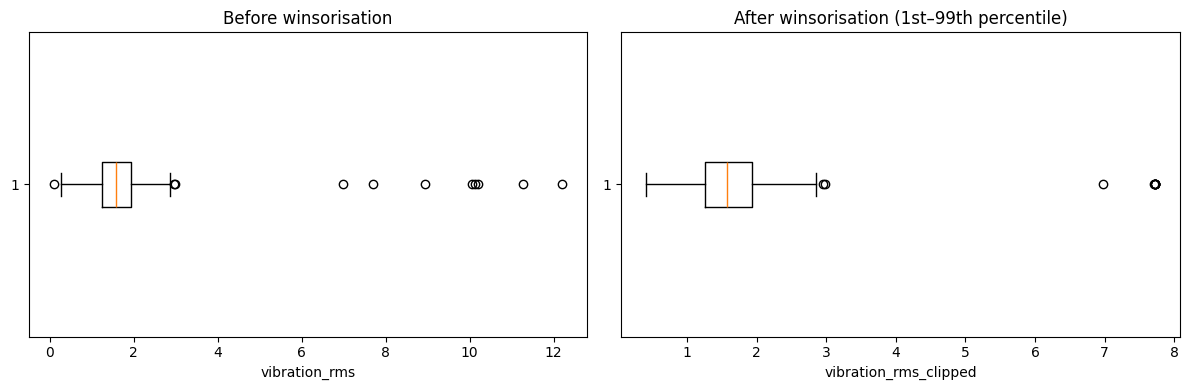

Clipping range: [0.42, 7.72]
Values clipped: 12


In [9]:
# =======================================================
# 3.5 OUTLIER HANDLING — WINSORISATION
# =======================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['vibration_rms'].dropna(), vert=False)
axes[0].set_title('Before winsorisation')
axes[0].set_xlabel('vibration_rms')

# Winsorise at 1st and 99th percentile
low, high = df['vibration_rms'].quantile(0.01), df['vibration_rms'].quantile(0.99)
df['vibration_rms_clipped'] = df['vibration_rms'].clip(low, high)

axes[1].boxplot(df['vibration_rms_clipped'].dropna(), vert=False)
axes[1].set_title('After winsorisation (1st–99th percentile)')
axes[1].set_xlabel('vibration_rms_clipped')

plt.tight_layout()
plt.show()

print(f"Clipping range: [{low:.2f}, {high:.2f}]")
print(f"Values clipped: {(df['vibration_rms'] != df['vibration_rms_clipped']).sum()}")


### 3.6 Categorical encoding

We have `vessel_class` (4 categories) and `noise_category` (4 categories). For low-cardinality categoricals, **one-hot encoding** is safe and straightforward.


In [10]:
# =======================================================
# 3.6 CATEGORICAL ENCODING — One-hot
# =======================================================
print("Vessel class distribution:")
print(df['vessel_class'].value_counts())
print(f"\nWe'll use OneHotEncoder inside the pipeline (next section)")


Vessel class distribution:
vessel_class
RoRo         163
Tanker       157
Container    146
Bulk         134
Name: count, dtype: int64

We'll use OneHotEncoder inside the pipeline (next section)


---
## Part 4: Engineered Features — Full Pipeline

Now let's build a **proper sklearn Pipeline** that:
1. Handles numeric features (impute → scale)
2. Handles categorical features (impute → one-hot)
3. Includes our engineered features

**Critical:** All preprocessing is inside the pipeline, so it's fit on training data only.


In [11]:
from sklearn.preprocessing import OneHotEncoder

# ----- Define feature groups -----
engineered_numeric = [
    # Original signals
    'rpm', 'speed_knots', 'draft_m', 'power_kw', 'wave_height_m',
    'oil_temp_C', 'coolant_temp_C', 'engine_age_years',
    'vibration_rms_clipped',
    # Engineered: ratios
    'power_per_speed', 'fuel_per_rpm',
    # Engineered: non-linear
    'wave_height_sq', 'log_power', 'rpm_squared', 'wave_speed_interaction',
    # Engineered: cyclical
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    # Engineered: missingness
    'oil_temp_missing', 'coolant_temp_missing',
    # Noise (kept intentionally — we want to see if selection removes them)
    'noise_sensor_1', 'noise_sensor_2', 'noise_sensor_3',
]

categorical_features = ['vessel_class', 'noise_category']

# ----- Build pipeline -----
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, engineered_numeric),
    ('cat', categorical_transformer, categorical_features),
])

# OLS with engineered features
engineered_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])

X_eng = df[engineered_numeric + categorical_features].copy()

eng_scores = cross_val_score(engineered_pipe, X_eng, y, cv=gkf,
                              groups=groups, scoring='r2')

print("=" * 55)
print("ENGINEERED FEATURES + OLS")
print("=" * 55)
print(f"R² per fold: {eng_scores.round(4)}")
print(f"Mean R²:     {eng_scores.mean():.4f} ± {eng_scores.std():.4f}")
print(f"Num features: {len(engineered_numeric)} numeric + {len(categorical_features)} categorical")
print(f"\nImprovement over baseline: +{(eng_scores.mean() - baseline_scores.mean()):.4f} R²")


ENGINEERED FEATURES + OLS
R² per fold: [0.8213 0.8818 0.8015 0.8697]
Mean R²:     0.8435 ± 0.0332
Num features: 24 numeric + 2 categorical

Improvement over baseline: +0.0626 R²


**The engineered features significantly improved the model!**

But we've also added noise features and redundant features. The model is larger than it needs to be. This is where **feature selection** comes in.

> **Discussion:** Can you identify which of the 25+ features are truly necessary? Could we achieve similar performance with fewer features?

---


## Part 5: Feature Selection

We'll explore three families of methods, progressing from simple to sophisticated:

| Family | Method | How it works |
|--------|--------|-------------|
| **Filter** | Correlation, Mutual Information | Score features independently of model |
| **Wrapper** | Recursive Feature Elimination (RFE) | Use model performance to rank |
| **Embedded** | Lasso, Elastic Net | Selection built into training |

### 5.1 Filter Method: Correlation Analysis


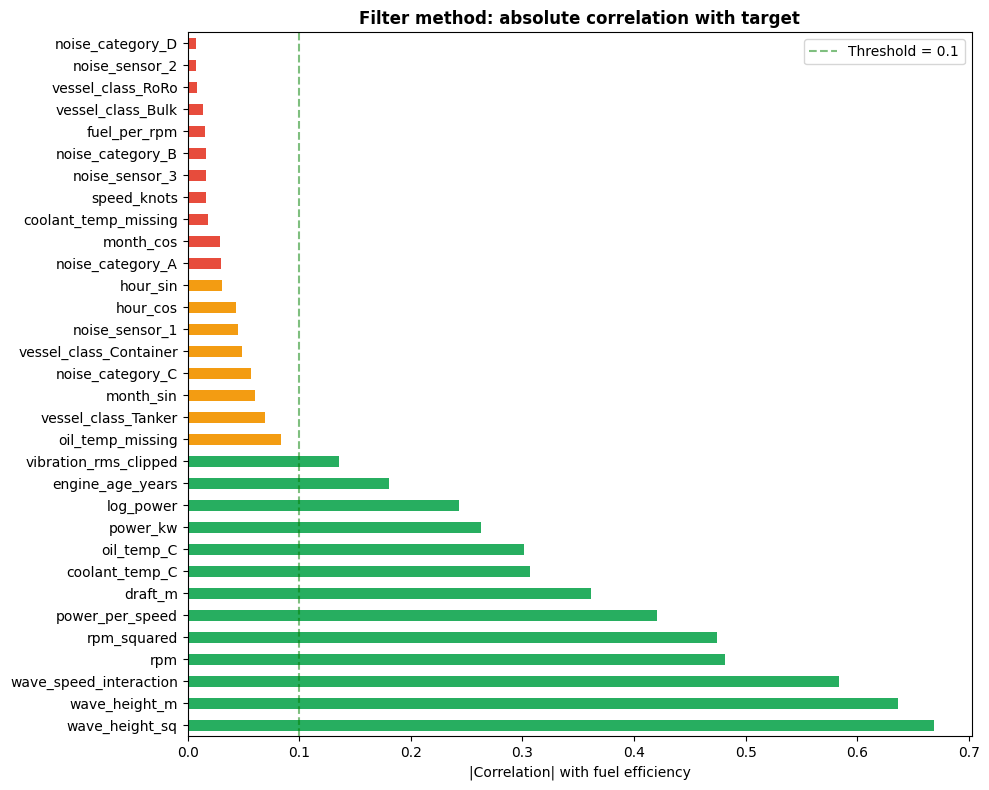


Top 10 features by |correlation|:
wave_height_sq            0.668874
wave_height_m             0.636552
wave_speed_interaction    0.583324
rpm                       0.481553
rpm_squared               0.474109
power_per_speed           0.420140
draft_m                   0.361793
coolant_temp_C            0.306369
oil_temp_C                0.301522
power_kw                  0.263124

Features below 0.03 threshold (likely noise):
['noise_category_A', 'month_cos', 'coolant_temp_missing', 'speed_knots', 'noise_sensor_3', 'noise_category_B', 'fuel_per_rpm', 'vessel_class_Bulk', 'vessel_class_RoRo', 'noise_sensor_2', 'noise_category_D']


In [12]:
# =======================================================
# 5.1 FILTER: Correlation with target
# =======================================================

# Fit the preprocessor to get transformed feature names
preprocessor_fitted = preprocessor.fit(X_eng)

# Get feature names after transformation
num_names = engineered_numeric
cat_names = list(preprocessor_fitted.named_transformers_['cat']
                 .named_steps['onehot'].get_feature_names_out(categorical_features))
all_feature_names = num_names + cat_names

# Transform data to compute correlations
X_transformed = preprocessor_fitted.transform(X_eng)
X_df = pd.DataFrame(X_transformed, columns=all_feature_names)

# Pre-compute GroupKFold splits for use with LassoCV, ElasticNetCV, RFECV
# (these estimators don't accept groups= directly in newer sklearn)
gkf_splits = list(gkf.split(X_transformed, y, groups=groups))

# Correlation with target
correlations = X_df.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#27ae60' if c > 0.1 else '#e74c3c' if c < 0.03 else '#f39c12'
          for c in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('|Correlation| with fuel efficiency')
ax.set_title('Filter method: absolute correlation with target', fontweight='bold')
ax.axvline(x=0.1, color='green', linestyle='--', alpha=0.5, label='Threshold = 0.1')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 features by |correlation|:")
print(correlations.head(10).to_string())
print(f"\nFeatures below 0.03 threshold (likely noise):")
print(correlations[correlations < 0.03].index.tolist())


**Observations:**
- The engineered features (`wave_height_sq`, `power_per_speed`) rank highly
- Noise features have near-zero correlation — the filter correctly identifies them
- **Limitation**: correlation is linear. It would miss a feature with a U-shaped relationship.

### 5.2 Filter Method: Mutual Information

Mutual Information captures **any** dependency, not just linear. It measures how much knowing $X$ reduces uncertainty about $Y$.


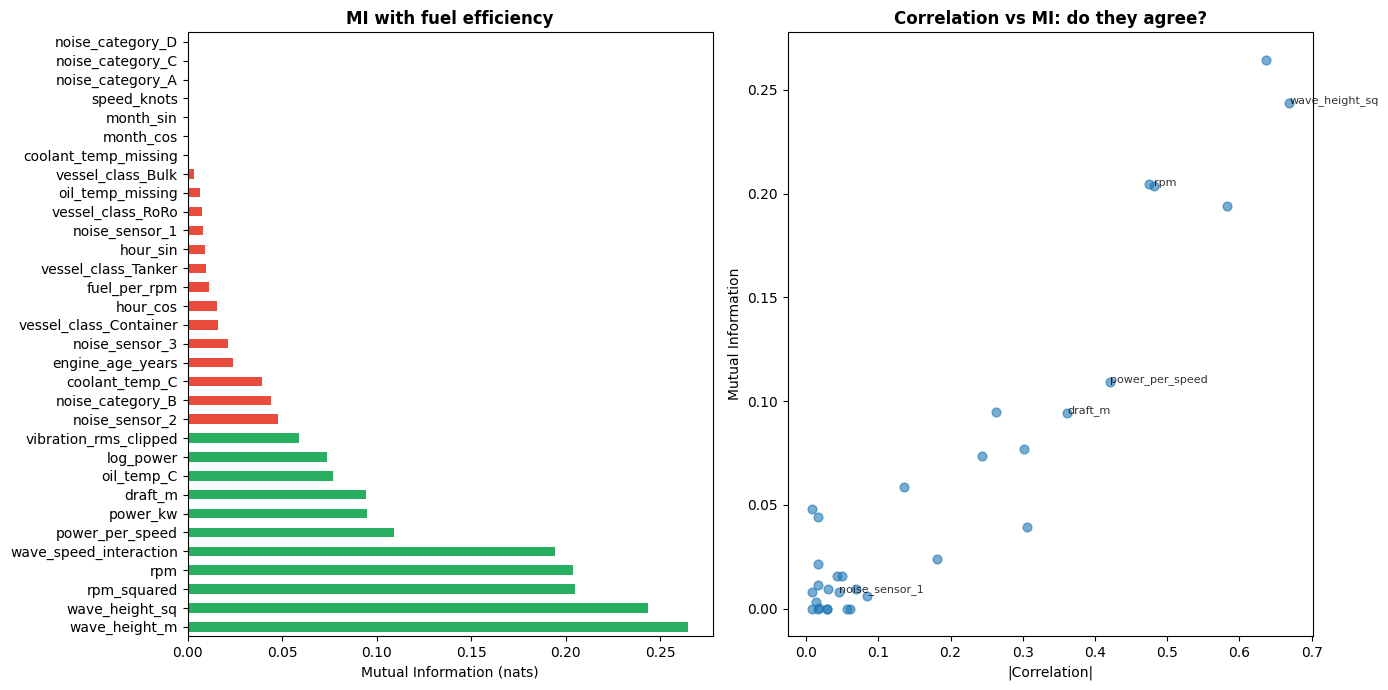

Top 10 features by MI:
wave_height_m             0.264439
wave_height_sq            0.243428
rpm_squared               0.204630
rpm                       0.203698
wave_speed_interaction    0.194053
power_per_speed           0.109001
power_kw                  0.094730
draft_m                   0.094232
oil_temp_C                0.077073
log_power                 0.073719


In [13]:
# =======================================================
# 5.2 FILTER: Mutual Information
# =======================================================
from sklearn.feature_selection import mutual_info_regression

# Compute MI (on the imputed/scaled data)
mi_scores = mutual_info_regression(X_transformed, y, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=all_feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: MI scores
colors_mi = ['#27ae60' if s > 0.05 else '#e74c3c' for s in mi_series.values]
mi_series.plot(kind='barh', ax=axes[0], color=colors_mi)
axes[0].set_xlabel('Mutual Information (nats)')
axes[0].set_title('MI with fuel efficiency', fontweight='bold')

# Right: Correlation vs MI comparison
axes[1].scatter(correlations[all_feature_names].values,
                mi_series[all_feature_names].values, alpha=0.6, s=40)
for feat in ['wave_height_sq', 'power_per_speed', 'noise_sensor_1', 'draft_m', 'rpm']:
    if feat in all_feature_names:
        x = correlations[feat]
        y_val = mi_series[feat]
        axes[1].annotate(feat, (x, y_val), fontsize=8, alpha=0.8)
axes[1].set_xlabel('|Correlation|')
axes[1].set_ylabel('Mutual Information')
axes[1].set_title('Correlation vs MI: do they agree?', fontweight='bold')

plt.tight_layout()
plt.show()

print("Top 10 features by MI:")
print(mi_series.head(10).to_string())


**Key insight:** MI and correlation mostly agree on the top features, but MI can detect non-linear dependencies that correlation misses. For our (mostly linear) dataset, they are fairly consistent.

### 5.3 Wrapper Method: Recursive Feature Elimination (RFE)

RFE trains a model, ranks features by importance, drops the least important, and repeats. It's model-aware but computationally expensive.


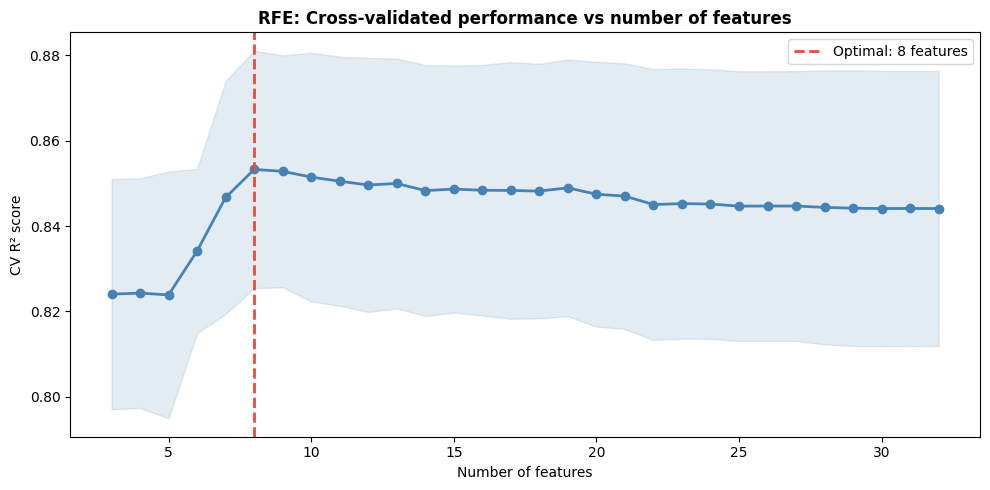

Optimal number of features: 8

Selected features (8):
  ✓ rpm
  ✓ speed_knots
  ✓ draft_m
  ✓ engine_age_years
  ✓ power_per_speed
  ✓ fuel_per_rpm
  ✓ wave_height_sq
  ✓ rpm_squared

Eliminated features (24):
  ✗ power_kw
  ✗ wave_height_m
  ✗ oil_temp_C
  ✗ coolant_temp_C
  ✗ vibration_rms_clipped
  ✗ log_power
  ✗ wave_speed_interaction
  ✗ hour_sin
  ✗ hour_cos
  ✗ month_sin
  ✗ month_cos
  ✗ oil_temp_missing
  ✗ coolant_temp_missing
  ✗ noise_sensor_1
  ✗ noise_sensor_2
  ✗ noise_sensor_3
  ✗ vessel_class_Bulk
  ✗ vessel_class_Container
  ✗ vessel_class_RoRo
  ✗ vessel_class_Tanker
  ✗ noise_category_A
  ✗ noise_category_B
  ✗ noise_category_C
  ✗ noise_category_D


In [14]:
# =======================================================
# 5.3 WRAPPER: RFE with cross-validation
# =======================================================
from sklearn.feature_selection import RFECV

# Use Ridge as the base estimator (handles multicollinearity better than OLS)
rfe_estimator = Ridge(alpha=1.0)

# RFECV with GroupKFold
rfecv = RFECV(
    estimator=rfe_estimator,
    step=1,                # remove 1 feature per iteration
    cv=gkf_splits,
    scoring='r2',
    min_features_to_select=3,
    n_jobs=-1,
)

# Fit on the preprocessed data
rfecv.fit(X_transformed, y)

# Plot number of features vs CV score
fig, ax = plt.subplots(figsize=(10, 5))
n_features_range = range(rfecv.min_features_to_select, len(all_feature_names) + 1)
cv_scores = rfecv.cv_results_['mean_test_score']
cv_std = rfecv.cv_results_['std_test_score']

ax.plot(n_features_range, cv_scores, 'o-', color='steelblue', lw=2)
ax.fill_between(n_features_range,
                cv_scores - cv_std,
                cv_scores + cv_std,
                alpha=0.15, color='steelblue')
ax.axvline(rfecv.n_features_, color='#e74c3c', linestyle='--', lw=2,
           label=f'Optimal: {rfecv.n_features_} features')
ax.set_xlabel('Number of features')
ax.set_ylabel('CV R² score')
ax.set_title('RFE: Cross-validated performance vs number of features', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Selected features
selected_mask = rfecv.support_
selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]
eliminated_features = [f for f, s in zip(all_feature_names, selected_mask) if not s]

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"\nSelected features ({len(selected_features)}):")
for f in selected_features:
    print(f"  ✓ {f}")
print(f"\nEliminated features ({len(eliminated_features)}):")
for f in eliminated_features:
    print(f"  ✗ {f}")


**Observations:**
- RFE correctly eliminates the noise features
- It removes some redundant features (e.g., `oil_temp_C` which is largely captured by `rpm`)
- The optimal feature count is much smaller than the full set, with minimal performance loss

> **Student exercise:** What happens if you use OLS instead of Ridge as the base estimator for RFE? Try it!

### 5.4 Embedded Method: Lasso (L₁ Regularisation)

You already know that Lasso drives coefficients to exactly zero. This is **simultaneous** model fitting and feature selection.


Optimal alpha: 0.014850
R² at optimal alpha: 0.8627


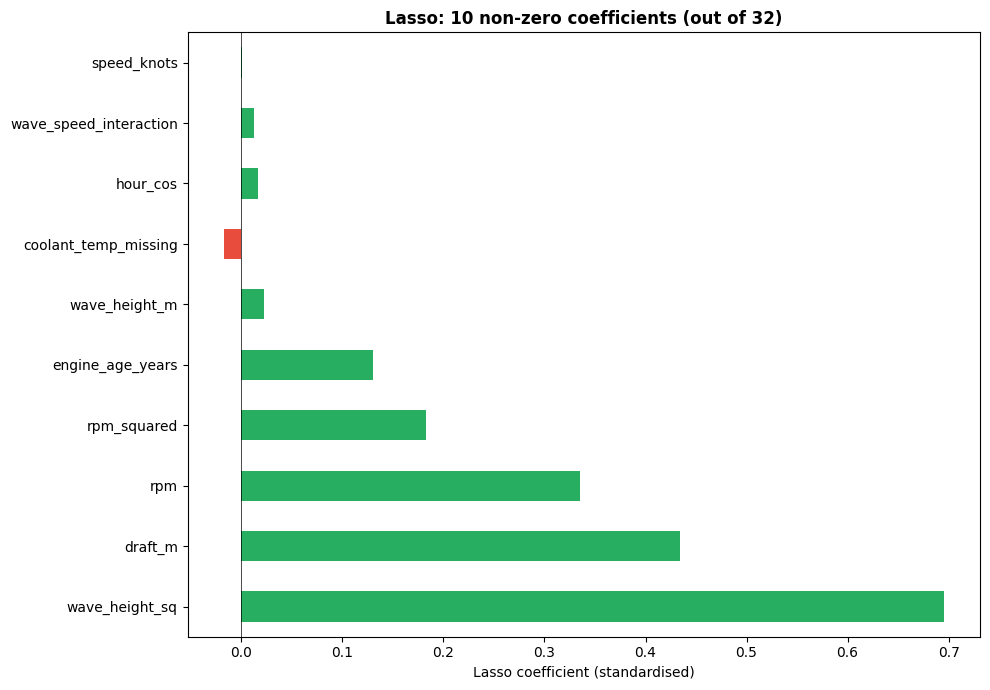


Non-zero features (10):
  wave_height_sq                      β = +0.6955
  draft_m                             β = +0.4338
  rpm                                 β = +0.3355
  rpm_squared                         β = +0.1824
  engine_age_years                    β = +0.1306
  wave_height_m                       β = +0.0220
  coolant_temp_missing                β = -0.0176
  hour_cos                            β = +0.0167
  wave_speed_interaction              β = +0.0120
  speed_knots                         β = +0.0009

Zeroed-out features (22):
  ✗ power_kw
  ✗ oil_temp_C
  ✗ coolant_temp_C
  ✗ vibration_rms_clipped
  ✗ power_per_speed
  ✗ fuel_per_rpm
  ✗ log_power
  ✗ hour_sin
  ✗ month_sin
  ✗ month_cos
  ✗ oil_temp_missing
  ✗ noise_sensor_1
  ✗ noise_sensor_2
  ✗ noise_sensor_3
  ✗ vessel_class_Bulk
  ✗ vessel_class_Container
  ✗ vessel_class_RoRo
  ✗ vessel_class_Tanker
  ✗ noise_category_A
  ✗ noise_category_B
  ✗ noise_category_C
  ✗ noise_category_D


In [15]:
# =======================================================
# 5.4 EMBEDDED: Lasso regularisation path
# =======================================================
from sklearn.linear_model import LassoCV

# Lasso with cross-validation to find optimal alpha
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 100),
    cv=gkf_splits,
    max_iter=10000,
    random_state=42,
)
lasso_cv.fit(X_transformed, y)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"R² at optimal alpha: {lasso_cv.score(X_transformed, y):.4f}")

# Coefficient analysis
lasso_coefs = pd.Series(lasso_cv.coef_, index=all_feature_names)
lasso_nonzero = lasso_coefs[lasso_coefs.abs() > 1e-8].sort_values(key=abs, ascending=False)
lasso_zero = lasso_coefs[lasso_coefs.abs() <= 1e-8]

fig, ax = plt.subplots(figsize=(10, 7))
colors_lasso = ['#27ae60' if v > 0 else '#e74c3c' for v in lasso_nonzero.values]
lasso_nonzero.plot(kind='barh', ax=ax, color=colors_lasso)
ax.set_xlabel('Lasso coefficient (standardised)')
ax.set_title(f'Lasso: {len(lasso_nonzero)} non-zero coefficients '
             f'(out of {len(all_feature_names)})', fontweight='bold')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

print(f"\nNon-zero features ({len(lasso_nonzero)}):")
for name, coef in lasso_nonzero.items():
    print(f"  {name:35s} β = {coef:+.4f}")
print(f"\nZeroed-out features ({len(lasso_zero)}):")
for name in lasso_zero.index:
    print(f"  ✗ {name}")


### 5.5 Embedded Method: Elastic Net

Elastic Net combines $L_1$ (sparsity) and $L_2$ (grouping) penalties. It handles correlated features better than pure Lasso.


In [16]:
# =======================================================
# 5.5 EMBEDDED: Elastic Net
# =======================================================
from sklearn.linear_model import ElasticNetCV

enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    alphas=np.logspace(-4, 1, 50),
    cv=gkf_splits,
    max_iter=10000,
    random_state=42,
)
enet_cv.fit(X_transformed, y)

enet_coefs = pd.Series(enet_cv.coef_, index=all_feature_names)
enet_nonzero = enet_coefs[enet_coefs.abs() > 1e-8]

print(f"Optimal alpha: {enet_cv.alpha_:.6f}, l1_ratio: {enet_cv.l1_ratio_:.2f}")
print(f"Non-zero features: {len(enet_nonzero)} / {len(all_feature_names)}")
print(f"R²: {enet_cv.score(X_transformed, y):.4f}")


Optimal alpha: 0.017575, l1_ratio: 0.90
Non-zero features: 9 / 32
R²: 0.8625


### 5.6 Comparison: Which method agrees with ground truth?

Since we *know* the true data-generating process, we can check which features each method correctly identifies.


In [17]:
# =======================================================
# 5.6 COMPARISON TABLE
# =======================================================
true_signal_features = {'rpm', 'draft_m', 'wave_height_sq', 'power_per_speed', 'engine_age_years'}
true_noise_features = {'noise_sensor_1', 'noise_sensor_2', 'noise_sensor_3',
                       'noise_category_A', 'noise_category_B', 'noise_category_C', 'noise_category_D'}

# Collect selections from each method
corr_threshold = 0.05
corr_selected = set(correlations[correlations >= corr_threshold].index)

mi_threshold = 0.02
mi_selected = set(mi_series[mi_series >= mi_threshold].index)

rfe_selected = set(selected_features)

lasso_selected = set(lasso_nonzero.index)

enet_selected = set(enet_nonzero.index)

# Build comparison table
methods = {
    'Correlation': corr_selected,
    'Mutual Info': mi_selected,
    'RFE (Ridge)': rfe_selected,
    'Lasso': lasso_selected,
    'Elastic Net': enet_selected,
}

print("=" * 70)
print("FEATURE SELECTION COMPARISON")
print("=" * 70)
print(f"{'Method':<15} {'Selected':>8} {'True ∩ Sel':>10} {'Noise ∩ Sel':>12} {'Precision':>10}")
print("-" * 70)

for name, selected in methods.items():
    true_hits = len(true_signal_features & selected)
    noise_hits = len(true_noise_features & selected)
    print(f"{name:<15} {len(selected):>8} {true_hits:>10}/{len(true_signal_features)}"
          f"     {noise_hits:>6}/{len(true_noise_features)}"
          f"     {true_hits/max(len(selected),1):>8.0%}")

print("\nTrue signal features:", true_signal_features)


FEATURE SELECTION COMPARISON
Method          Selected True ∩ Sel  Noise ∩ Sel  Precision
----------------------------------------------------------------------
Correlation           17          5/5          1/7          29%
Mutual Info           16          5/5          3/7          31%
RFE (Ridge)            8          5/5          0/7          62%
Lasso                 10          4/5          0/7          40%
Elastic Net            9          4/5          0/7          44%

True signal features: {'wave_height_sq', 'engine_age_years', 'power_per_speed', 'rpm', 'draft_m'}


### 5.7 The Lasso Regularisation Path (Visualised)

This plot shows how coefficients shrink as regularisation strength ($\lambda$) increases. Features that survive longer are more important.


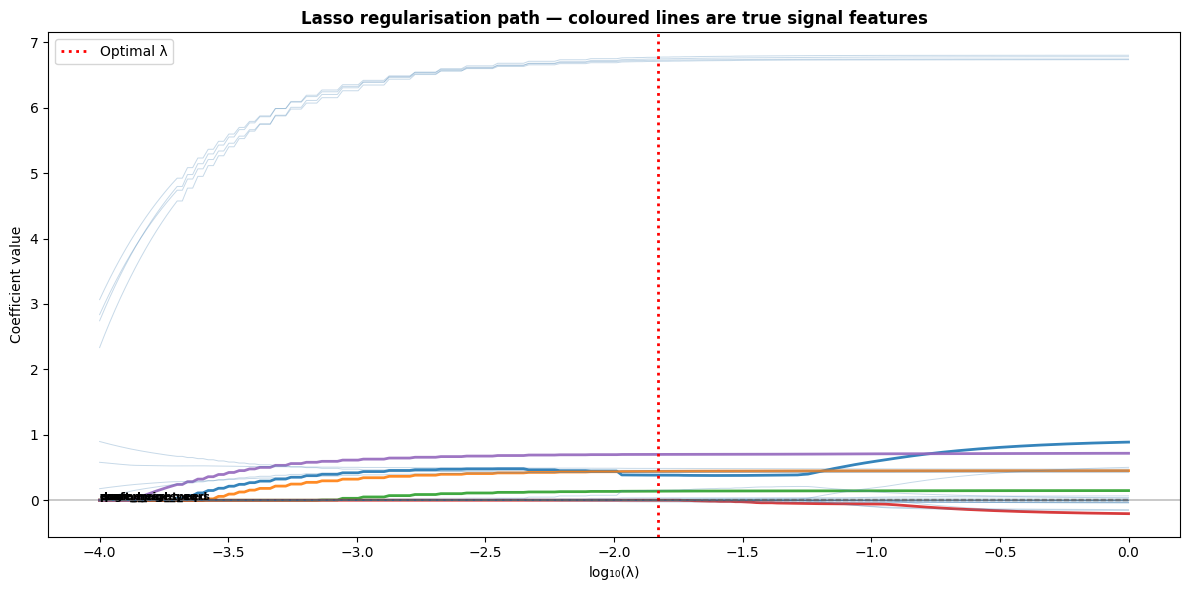

As λ increases (left to right), noise features drop out first.
True signal features persist until much higher regularisation.


In [18]:
# =======================================================
# 5.7 LASSO REGULARISATION PATH
# =======================================================
from sklearn.linear_model import lasso_path

# Compute the full Lasso path
alphas_path = np.logspace(-4, 0, 200)
_, coefs_path, _ = lasso_path(X_transformed, y, alphas=alphas_path)

fig, ax = plt.subplots(figsize=(12, 6))

# Color important features differently
important_idx = [all_feature_names.index(f) for f in true_signal_features if f in all_feature_names]
noise_idx = [all_feature_names.index(f) for f in ['noise_sensor_1', 'noise_sensor_2', 'noise_sensor_3']
             if f in all_feature_names]

for i in range(coefs_path.shape[0]):
    if i in important_idx:
        ax.plot(np.log10(alphas_path), coefs_path[i], lw=2, alpha=0.9)
        # Label at left end
        ax.annotate(all_feature_names[i], (-4, coefs_path[i, 0]),
                   fontsize=8, fontweight='bold')
    elif i in noise_idx:
        ax.plot(np.log10(alphas_path), coefs_path[i], '--', lw=1, color='gray', alpha=0.5)
    else:
        ax.plot(np.log10(alphas_path), coefs_path[i], lw=0.7, alpha=0.3, color='steelblue')

ax.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle=':', lw=2, label=f'Optimal λ')
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso regularisation path — coloured lines are true signal features',
             fontweight='bold')
ax.legend()
ax.axhline(0, color='black', lw=0.3)
plt.tight_layout()
plt.show()

print("As λ increases (left to right), noise features drop out first.")
print("True signal features persist until much higher regularisation.")


---
## Part 6: Data Leakage — A Cautionary Tale

This is the most common failure mode in applied ML. Let's demonstrate it concretely.

### 6.1 What leakage looks like


In [19]:
# =======================================================
# 6.1 LEAKAGE DEMONSTRATION
# =======================================================
from sklearn.preprocessing import StandardScaler as SS

# ──────────────────────────────────────────────────
# WRONG: fit scaler on ALL data, then cross-validate
# ──────────────────────────────────────────────────
X_numeric_raw = df[raw_numeric].copy()
imputer_wrong = SimpleImputer(strategy='median')
X_imputed_wrong = imputer_wrong.fit_transform(X_numeric_raw)  # fitted on ALL data!
scaler_wrong = SS()
X_scaled_wrong = scaler_wrong.fit_transform(X_imputed_wrong)  # fitted on ALL data!

ols_wrong = LinearRegression()
scores_wrong = cross_val_score(ols_wrong, X_scaled_wrong, y, cv=gkf,
                                groups=groups, scoring='r2')

# ──────────────────────────────────────────────────
# RIGHT: everything inside a Pipeline
# ──────────────────────────────────────────────────
pipe_right = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', SS()),
    ('model', LinearRegression()),
])
scores_right = cross_val_score(pipe_right, X_numeric_raw, y, cv=gkf,
                                groups=groups, scoring='r2')

print("=" * 60)
print("LEAKAGE DEMONSTRATION")
print("=" * 60)
print(f"\n❌ WRONG (scaler fit on all data): R² = {scores_wrong.mean():.4f} ± {scores_wrong.std():.4f}")
print(f"✅ RIGHT (scaler inside pipeline): R² = {scores_right.mean():.4f} ± {scores_right.std():.4f}")
print(f"\nDifference: {scores_wrong.mean() - scores_right.mean():+.4f}")
print("\n→ The 'wrong' approach appears slightly BETTER, but that's an illusion.")
print("  The leaked information makes CV scores optimistic.")
print("  In production, the 'wrong' model would perform WORSE than expected.")


LEAKAGE DEMONSTRATION

❌ WRONG (scaler fit on all data): R² = 0.7810 ± 0.0149
✅ RIGHT (scaler inside pipeline): R² = 0.7810 ± 0.0149

Difference: +0.0000

→ The 'wrong' approach appears slightly BETTER, but that's an illusion.
  The leaked information makes CV scores optimistic.
  In production, the 'wrong' model would perform WORSE than expected.


### 6.2 A more dramatic leakage: using a post-outcome variable

Imagine we accidentally include `days_since_last_repair` — a variable that is only recorded *after* a maintenance event (i.e., after the outcome has been observed).


In [20]:
# =======================================================
# 6.2 DRAMATIC LEAKAGE: Post-outcome variable
# =======================================================

# Simulate a post-outcome "leaky" feature: correlated with target because
# it was computed AFTER observing the outcome
np.random.seed(123)
leaky_feature = fuel_efficiency * 0.8 + np.random.normal(0, 0.5, n_samples)

X_with_leak = X_numeric_raw.copy()
X_with_leak['LEAKY_days_since_repair'] = leaky_feature

pipe_leaked = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', SS()),
    ('model', LinearRegression()),
])

scores_leaked = cross_val_score(pipe_leaked, X_with_leak, y, cv=gkf,
                                 groups=groups, scoring='r2')

print("=" * 60)
print("DRAMATIC LEAKAGE: Post-outcome variable")
print("=" * 60)
print(f"\n✅ Without leaky feature: R² = {scores_right.mean():.4f}")
print(f"❌ With leaky feature:    R² = {scores_leaked.mean():.4f}")
print(f"\n⚠️  The leaky model looks MUCH better — but it's CHEATING.")
print("   This feature would not be available at prediction time.")
print("\n→ Rule: If a feature seems 'too good to be true', investigate its causal direction!")


DRAMATIC LEAKAGE: Post-outcome variable

✅ Without leaky feature: R² = 0.7810
❌ With leaky feature:    R² = 0.8603

⚠️  The leaky model looks MUCH better — but it's CHEATING.
   This feature would not be available at prediction time.

→ Rule: If a feature seems 'too good to be true', investigate its causal direction!


---
## Part 7: Stability Selection

Lasso selection is sensitive to which samples happen to be in your dataset. **Stability selection** addresses this by running Lasso on many random subsamples and keeping features that are *consistently* selected.


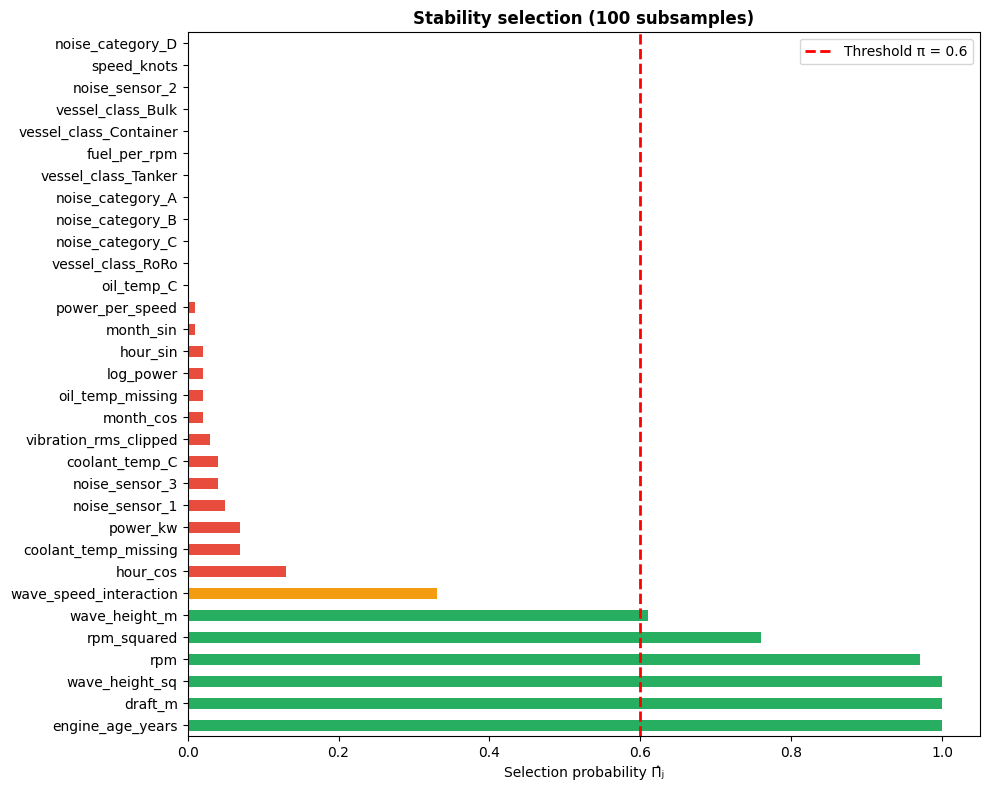


Stable features (Π ≥ 0.6): 6
  ✓ engine_age_years (Π = 1.00)
  ✓ draft_m (Π = 1.00)
  ✓ wave_height_sq (Π = 1.00)
  ✓ rpm (Π = 0.97)
  ✓ rpm_squared (Π = 0.76)
  ✓ wave_height_m (Π = 0.61)

Unstable features (Π < 0.3):
  ✗ hour_cos (Π = 0.13)
  ✗ coolant_temp_missing (Π = 0.07)
  ✗ power_kw (Π = 0.07)
  ✗ noise_sensor_1 (Π = 0.05)
  ✗ noise_sensor_3 (Π = 0.04)
  ✗ coolant_temp_C (Π = 0.04)
  ✗ vibration_rms_clipped (Π = 0.03)
  ✗ month_cos (Π = 0.02)
  ✗ oil_temp_missing (Π = 0.02)
  ✗ log_power (Π = 0.02)
  ✗ hour_sin (Π = 0.02)
  ✗ month_sin (Π = 0.01)
  ✗ power_per_speed (Π = 0.01)
  ✗ oil_temp_C (Π = 0.00)
  ✗ vessel_class_RoRo (Π = 0.00)
  ✗ noise_category_C (Π = 0.00)
  ✗ noise_category_B (Π = 0.00)
  ✗ noise_category_A (Π = 0.00)
  ✗ vessel_class_Tanker (Π = 0.00)
  ✗ fuel_per_rpm (Π = 0.00)
  ✗ vessel_class_Container (Π = 0.00)
  ✗ vessel_class_Bulk (Π = 0.00)
  ✗ noise_sensor_2 (Π = 0.00)
  ✗ speed_knots (Π = 0.00)
  ✗ noise_category_D (Π = 0.00)


In [21]:
# =======================================================
# 7. STABILITY SELECTION (manual implementation)
# =======================================================
from sklearn.linear_model import Lasso
from sklearn.utils import resample

n_bootstrap = 100
alpha_stability = 0.05  # moderate regularisation
selection_counts = np.zeros(len(all_feature_names))

for b in range(n_bootstrap):
    # Random subsample (50% of data)
    idx = resample(range(len(y)), n_samples=len(y)//2, random_state=b, replace=False)
    X_sub = X_transformed[idx]
    y_sub = y.iloc[idx].values

    lasso_b = Lasso(alpha=alpha_stability, max_iter=10000)
    lasso_b.fit(X_sub, y_sub)

    # Count which features have non-zero coefficients
    selection_counts += (np.abs(lasso_b.coef_) > 1e-8).astype(int)

# Selection probability
selection_prob = selection_counts / n_bootstrap
stab_series = pd.Series(selection_prob, index=all_feature_names).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors_stab = ['#27ae60' if p >= 0.6 else '#f39c12' if p >= 0.3 else '#e74c3c'
               for p in stab_series.values]
stab_series.plot(kind='barh', ax=ax, color=colors_stab)
ax.axvline(0.6, color='red', linestyle='--', lw=2, label='Threshold π = 0.6')
ax.set_xlabel('Selection probability Π̂ⱼ')
ax.set_title(f'Stability selection ({n_bootstrap} subsamples)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

stable_features = stab_series[stab_series >= 0.6].index.tolist()
print(f"\nStable features (Π ≥ 0.6): {len(stable_features)}")
for f in stable_features:
    print(f"  ✓ {f} (Π = {stab_series[f]:.2f})")

print(f"\nUnstable features (Π < 0.3):")
for f in stab_series[stab_series < 0.3].index:
    print(f"  ✗ {f} (Π = {stab_series[f]:.2f})")


---
## Part 8: Final Model Comparison

Let's compare all approaches head-to-head:


FINAL MODEL COMPARISON (GroupKFold CV, R²)
Model                           Mean R²    ± Std   # Features
----------------------------------------------------------------------
Baseline (raw + OLS)             0.7810   0.0149           14
Engineered + OLS                 0.8435   0.0332           26
Engineered + Ridge               0.8441   0.0322           26
Engineered + Lasso               0.8494   0.0272           26
Stable features + OLS            0.8526   0.0263            6
RFE-selected + OLS               0.8544   0.0288            8


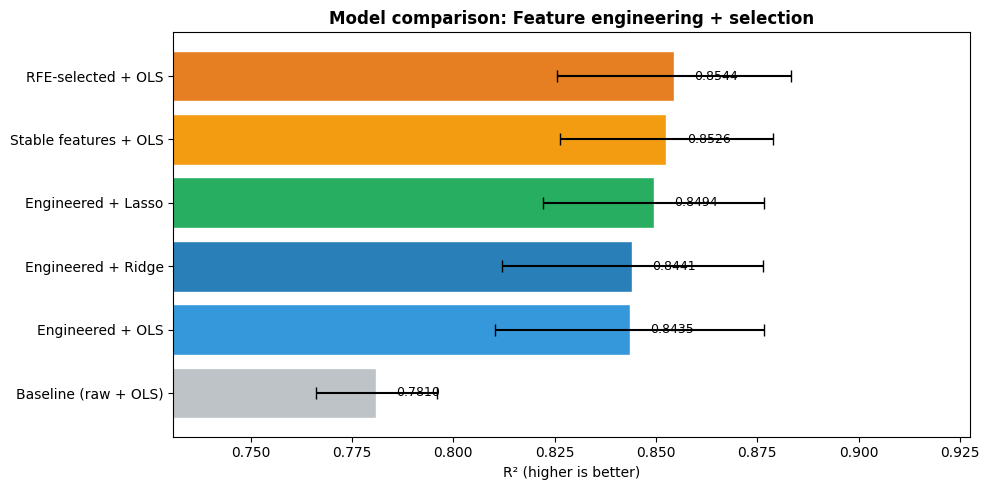

In [22]:
# =======================================================
# 8. FINAL COMPARISON
# =======================================================
from sklearn.linear_model import ElasticNet

results = {}

# 1. Baseline: raw features + OLS
results['Baseline (raw + OLS)'] = baseline_scores

# 2. Engineered + OLS (all features)
results['Engineered + OLS'] = eng_scores

# 3. Engineered + Ridge
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0)),
])
results['Engineered + Ridge'] = cross_val_score(pipe_ridge, X_eng, y,
    cv=gkf, groups=groups, scoring='r2')

# 4. Engineered + Lasso (automatic selection)
pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=lasso_cv.alpha_, max_iter=10000)),
])
results['Engineered + Lasso'] = cross_val_score(pipe_lasso, X_eng, y,
    cv=gkf, groups=groups, scoring='r2')

# 5. Stability-selected features + OLS
stable_numeric = [f for f in stable_features if f in engineered_numeric]
stable_cat = [f for f in stable_features
              if any(f.startswith(c) for c in categorical_features)]
# Map one-hot names back to original categoricals
stable_cat_orig = [c for c in categorical_features
                   if any(f.startswith(c) for f in stable_features)]

stable_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, stable_numeric),
    ('cat', categorical_transformer, stable_cat_orig) if stable_cat_orig else ('cat', 'drop', []),
])
pipe_stable = Pipeline([
    ('preprocessor', stable_preprocessor),
    ('model', LinearRegression()),
])
X_stable = df[stable_numeric + stable_cat_orig].copy() if stable_cat_orig else df[stable_numeric].copy()
results['Stable features + OLS'] = cross_val_score(pipe_stable, X_stable, y,
    cv=gkf, groups=groups, scoring='r2')

# 6. RFE-selected features + OLS
rfe_numeric = [f for f in selected_features if f in engineered_numeric]
rfe_cat_orig = [c for c in categorical_features
                if any(f.startswith(c) for f in selected_features)]
rfe_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, rfe_numeric),
    ('cat', categorical_transformer, rfe_cat_orig) if rfe_cat_orig else ('cat', 'drop', []),
])
pipe_rfe = Pipeline([
    ('preprocessor', rfe_preprocessor),
    ('model', LinearRegression()),
])
X_rfe = df[rfe_numeric + rfe_cat_orig].copy() if rfe_cat_orig else df[rfe_numeric].copy()
results['RFE-selected + OLS'] = cross_val_score(pipe_rfe, X_rfe, y,
    cv=gkf, groups=groups, scoring='r2')

# ------- Summary table -------
print("=" * 70)
print("FINAL MODEL COMPARISON (GroupKFold CV, R²)")
print("=" * 70)
print(f"{'Model':<30} {'Mean R²':>8} {'± Std':>8} {'# Features':>12}")
print("-" * 70)
for name, scores in results.items():
    n_feat = '—'
    if 'Baseline' in name: n_feat = str(len(raw_numeric))
    elif 'Engineered' in name: n_feat = str(len(engineered_numeric) + len(categorical_features))
    elif 'Stable' in name: n_feat = str(len(stable_numeric) + len(stable_cat_orig))
    elif 'RFE' in name: n_feat = str(len(rfe_numeric) + len(rfe_cat_orig))
    elif 'Lasso' in name: n_feat = f'{len(lasso_nonzero)}'
    print(f"{name:<30} {scores.mean():>8.4f} {scores.std():>8.4f} {n_feat:>12}")

# ------- Visual comparison -------
fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(results))
names = list(results.keys())
means = [v.mean() for v in results.values()]
stds = [v.std() for v in results.values()]

bars = ax.barh(positions, means, xerr=stds, color=[
    '#bdc3c7', '#3498db', '#2980b9', '#27ae60', '#f39c12', '#e67e22'],
    edgecolor='white', capsize=4)
ax.set_yticks(positions)
ax.set_yticklabels(names)
ax.set_xlabel('R² (higher is better)')
ax.set_title('Model comparison: Feature engineering + selection', fontweight='bold')
ax.set_xlim(left=min(means) - 0.05)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### Key takeaways from the comparison

1. **Feature engineering** provides the biggest single improvement — domain knowledge beats algorithmic cleverness
2. **Feature selection** (Lasso, stability, RFE) achieves comparable performance with fewer features
3. The **simplest model that works** is often the best for deployment — fewer features = less maintenance, faster inference, easier debugging
4. **Lasso and stability selection** correctly eliminated the noise features

---


## Part 9: Prediction vs Causal Feature Selection (Brief Introduction)

When we select features for **prediction**, we want any feature correlated with the target.

When we select features for **causal inference**, we must be careful about the causal structure:

| Structure | Example | Action |
|-----------|---------|--------|
| **Confounder** (Z → X, Z → Y) | Sea state affects both fuel use & speed | **Include Z** |
| **Mediator** (X → M → Y) | Fuel quality → soot → engine failure | **Exclude M** (if you want total effect of X) |
| **Collider** (X → C ← Y) | Both speed & efficiency affect "alarm triggered" | **Exclude C** |

> In our maritime scenario, `oil_temp` is a **mediator**: RPM → oil temperature → fuel consumption. Including it in a *causal* model of RPM's effect would block the causal path, but for *prediction* it's fine.


---
## Part 10: Exercises

### Exercise 1: Polynomial Feature Expansion
Create polynomial features of degree 2 using `sklearn.preprocessing.PolynomialFeatures` on the top 5 features selected by Lasso. How does it affect R²? Does it overfit?

### Exercise 2: Target Encoding
The `vessel_class` feature has only 4 categories. But imagine we had `port_id` with 500+ ports. Implement K-fold target encoding (using `sklearn.model_selection.KFold` to compute out-of-fold means) and compare with one-hot encoding.

### Exercise 3: Feature Importance from Random Forest
Fit a `RandomForestRegressor` and compare its `feature_importances_` with the Lasso coefficients. Do they agree on the top features? Try permutation importance (`sklearn.inspection.permutation_importance`) — is it more or less biased?

### Exercise 4: Leakage Detective
A colleague gives you a model with R² = 0.99. They used these features:
- `rpm`, `draft_m`, `wave_height_m`
- `repair_cost` (logged after the maintenance event)
- `efficiency_category` (a binned version of the target)

Which features are leaking? How would you verify?

### Exercise 5: Stability Selection Threshold
Vary the stability selection threshold from 0.3 to 0.9. Plot the number of selected features vs threshold. Is there a natural "elbow"?

---

## References

1. Guyon, I., & Elisseeff, A. (2003). An introduction to variable and feature selection. *JMLR*, 3, 1157–1182.
2. Meinshausen, N., & Bühlmann, P. (2010). Stability selection. *JRSS-B*, 72(4), 417–473.
3. Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press.
4. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Chapters 3, 7.
